<a href="https://colab.research.google.com/github/Lanvry/Mechine-Learning/blob/main/Flower_Clasification_Mechine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Menginstall Kaggle API Dan mengunduh dataset gambar bunga

In [3]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle Api Telahg di atur")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle Api Telahg di atur


2. Mengunduh Dataset Bunga

In [4]:
!kaggle datasets download -d alxmamaev/flowers-recognition

print("Dataset Telah diunduh")

Dataset URL: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition
License(s): unknown
100% 225M/225M [00:15<00:00, 15.2MB/s]

Dataset Telah diunduh


3. Import **Library**

In [14]:
import os
import zipfile
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

4. Membongkar Dataset

In [6]:
zip_file_name = 'flowers-recognition.zip'

destination_dir = 'flowers'
os.makedirs(destination_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
  zip_ref.extractall(destination_dir)

print("Data Set Telah Di Bongkar")

Data Set Telah Di Bongkar


5. Pra-Proses Data dan Augumentasi Data

In [12]:
IMG_WIDTH = 150
IMG_HEIGHT = 150
BATCH_SIZE = 32

data_dir = os.path.join(destination_dir, 'flowers')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = validation_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print("Data Generator Berhasil Di Buat")

Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.
Data Generator Berhasil Di Buat


6. Membuat Model Convolutional Neural Network (CNN)

In [15]:
model_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dense(train_generator.num_classes, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()
print("Model CNN Berhasil dibangun dan dikompilkasi")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,036,229 (72.62 MB)

 Trainable params: 19,036,229 (72.62 MB)

 Non-trainable params: 0 (0.00 B)

Model CNN Berhasil dibangun dan dikompilkasi


7. Training Model CNN

In [16]:
from IPython.core import history
history = model_cnn.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=15,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

print("Model CNN telah Di train")

Epoch 1/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 36s 273ms/step - accuracy: 0.4333 - loss: 1.3432 - val_accuracy: 0.5409 - val_loss: 1.1415
Epoch 2/15
  1/108 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5625 - loss: 1.0510

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5625 - loss: 1.0510 - val_accuracy: 0.5180 - val_loss: 1.1866
Epoch 3/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 27s 250ms/step - accuracy: 0.5562 - loss: 1.0834 - val_accuracy: 0.6010 - val_loss: 1.0148
Epoch 4/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4688 - loss: 1.2028 - val_accuracy: 0.5974 - val_loss: 1.0427
Epoch 5/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 38s 239ms/step - accuracy: 0.6076 - loss: 1.0039 - val_accuracy: 0.6142 - val_loss: 1.0017
Epoch 6/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4375 - loss: 1.1927 - val_accuracy: 0.6046 - val_loss: 1.0534
Epoch 7/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 25s 234ms/step - accuracy: 0.6161 - loss: 0.9584 - val_accuracy: 0.6298 - val_loss: 0.9616
Epoch 8/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5938 - loss: 0.9645 - val_accuracy: 0.5925 - val_loss: 1.0281
Epoch 9/15
108/108 ━━━━━━━━━━━━━━━━━━━━ 26s 235ms/step - accuracy: 0.6415 - loss: 0.9122 - val_accurac

8. Mengevaluasi Kinerja MODEL CNN

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.7093 - loss: 0.8041
Loss: 0.8040946125984192, Accuracy: 0.7093023061752319


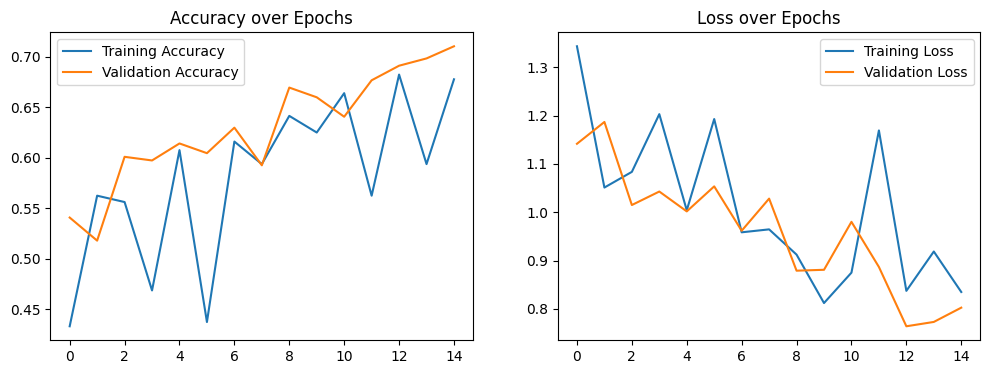

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step

Classification Report:
              precision    recall  f1-score   support

       daisy       0.14      0.17      0.15       152
   dandelion       0.24      0.19      0.21       210
        rose       0.25      0.21      0.23       156
   sunflower       0.16      0.19      0.17       146
       tulip       0.23      0.25      0.24       196

    accuracy                           0.20       860
   macro avg       0.20      0.20      0.20       860
weighted avg       0.21      0.20      0.20       860


 Confussion Matrix:
[[26 33 24 28 41]
 [46 39 30 47 48]
 [36 21 32 31 36]
 [36 27 20 28 35]
 [40 44 21 42 49]]


In [20]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import importlib

# Attempt to reload matplotlib.pyplot to refresh its state
importlib.reload(plt)

loss, accuracy = model_cnn.evaluate(validation_generator)
print(f'Loss: {loss}, Accuracy: {accuracy}')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

y_pred_prob = model_cnn.predict(validation_generator)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = validation_generator.classes

class_labels = list(train_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

print("\n Confussion Matrix:")
print(confusion_matrix(y_true, y_pred))

9. Membuat Prediksi Dengan Data Baru

Memprediksi gambar: flowers/flowers/rose/15174615529_144ae28bdb_n.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


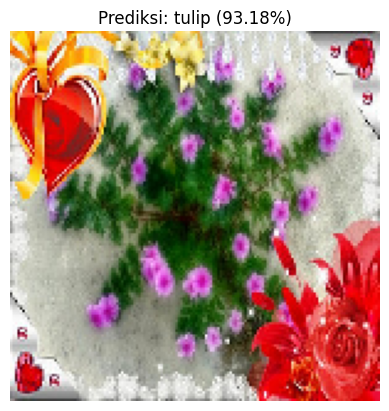

Model memprediksi ini adalah tulip dengan keyakinan 93.18%


In [28]:
from tensorflow.keras.preprocessing import image

def predict_image(image_path):
    img = image.load_img(image_path, target_size=(IMG_WIDTH, IMG_HEIGHT))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    predictions = model_cnn.predict(img_array)
    predicted_class_index = np.argmax(predictions[0])
    predicted_class_name = class_labels[predicted_class_index]
    confidence = predictions[0][predicted_class_index] * 100

    plt.imshow(img)
    plt.title(f"Prediksi: {predicted_class_name} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    return predicted_class_name, confidence

rose_dir_path = os.path.join(data_dir, 'rose')
example_image_path = os.path.join(rose_dir_path, os.listdir(rose_dir_path)[0])

print(f"Memprediksi gambar: {example_image_path}")
predicted_species, conf = predict_image(example_image_path)
print(f"Model memprediksi ini adalah {predicted_species} dengan keyakinan {conf:.2f}%")